In [1]:
#pip install polars elfen spacy

In [2]:
#  !Python -m spacy download en_core_web_sm

In [3]:
# !pip install scikit-bio   # FOR MENTAL TEST FUNCTION 

import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import LocalOutlierFactor
from skbio.stats.distance import mantel
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, roc_curve
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import permutation_test_score
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import warnings

In [4]:
import polars as pl
from pathlib import Path

folder = Path("/Users/ayanguin/Library/CloudStorage/GoogleDrive-ayanguin9@gmail.com/My Drive/Colab Notebooks/NLP Poster")
csv_files = list(folder.glob("*.csv"))

dataframes = {}

for f in csv_files:
    key = f.stem.split("_")[0]
    print(f)
    print(key)
    dataframes[key] = pl.read_csv(f)

/Users/ayanguin/Library/CloudStorage/GoogleDrive-ayanguin9@gmail.com/My Drive/Colab Notebooks/NLP Poster/QWEN_dataset_experiment_results.csv
QWEN
/Users/ayanguin/Library/CloudStorage/GoogleDrive-ayanguin9@gmail.com/My Drive/Colab Notebooks/NLP Poster/HuggingFaceTB_dataset_experiment_results.csv
HuggingFaceTB
/Users/ayanguin/Library/CloudStorage/GoogleDrive-ayanguin9@gmail.com/My Drive/Colab Notebooks/NLP Poster/mistralai_dataset_experiment_results.csv
mistralai
/Users/ayanguin/Library/CloudStorage/GoogleDrive-ayanguin9@gmail.com/My Drive/Colab Notebooks/NLP Poster/google_dataset_experiment_results.csv
google
/Users/ayanguin/Library/CloudStorage/GoogleDrive-ayanguin9@gmail.com/My Drive/Colab Notebooks/NLP Poster/meta-llama_dataset_experiment_results.csv
meta-llama


In [5]:
from pathlib import Path

def elfen_feature(data, key):

    import elfen
    from elfen import Extractor

    # ----------------------------------------------------
    # B. initializing Elfen
    # ----------------------------------------------------
    print("\nInitializing elfen feature extractor...")
    extractor = Extractor(
        data,
        language="en",
        backbone="spacy",
        text_column="unconstrained_text"
    )

    print("Extracting 1,061 linguistic features...")
    extractor.extract_features()
    df_features = extractor.get_data()



    import polars as pl

    # Iterate over columns and cast any remaining Object, List, or Struct columns to String
    # This is a more robust way to ensure all complex/nested objects are converted to a string representation
    for col in df_features.columns:
        if df_features[col].dtype in (pl.Object, pl.List, pl.Struct):
            df_features = df_features.with_columns(
                pl.col(col).map_elements(lambda x: str(x), return_dtype=pl.String)
            )

    # Now Polars can safely write it to a CSV
    Path(f"{key}").mkdir(exist_ok=True)
    df_features.write_csv(f"result/{key}_sample_features.csv")

In [6]:
def ling_finger(data, key):

    # 1. Load the exported feature dataset
    df = pl.read_csv(data)

    # 2. Separate metadata columns from numeric linguistic features
    metadata_cols = ["question_id", "first_token_answer", "unconstrained_text", "parsed_text_answer", "is_mismatch"]
    feature_cols = [col for col in df.columns if col not in metadata_cols]

    print(f"Total Rows Analyzed: {len(df)}")
    print(f"Total Linguistic Features: {len(feature_cols)}")
    print(f"Overall Mismatch Rate: {df['is_mismatch'].mean():.2%}")

    # 3. Identify Top Distinguishing Linguistic Features (Matched vs. Mismatched)
    df_pd = df.to_pandas()

    # Convert boolean mismatch to integer for correlation
    df_pd["mismatch_numeric"] = df_pd["is_mismatch"].astype(int)

    # Filter strictly numeric feature columns
    numeric_features = df_pd[feature_cols].select_dtypes(include=[np.number]).columns

    # Calculate correlation between linguistic features and mismatch occurrence
    correlations = df_pd[numeric_features].apply(lambda x: x.corr(df_pd["mismatch_numeric"])).dropna()

    # Sort top positively and negatively correlated features
    top_features = correlations.abs().sort_values(ascending=False).head(10)
    print("\n--- TOP 10 CORRELATED LINGUISTIC FEATURES ---")
    print(correlations[top_features.index])

    # 4. Generate Poster Visual: Top Feature Importance Bar Chart
    plt.figure(figsize=(10, 5))
    sns.barplot(x=correlations[top_features.index].values, y=top_features.index, palette="viridis")
    plt.axvline(0, color="black", linestyle="--", linewidth=0.8)
    plt.title(f"{key} Top Linguistic Fingerprints Driving Evaluation Instability (is_mismatch)", fontsize=13, pad=12)
    plt.xlabel("Correlation with Mismatch (r)", fontsize=11)
    plt.ylabel("elfen Linguistic Feature", fontsize=11)
    plt.tight_layout()
    plt.savefig(f"{key}/{key}_feature_importance_poster.png", dpi=300)
    plt.show()

In [7]:

def mismatch_classifier(data, key, run_permutation=True):
    df = pl.read_csv(data).to_pandas()

    warnings.filterwarnings("ignore", category=FutureWarning, module="sklearn")
    warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")

    metadata_cols = ["question_id", "first_token_answer", "unconstrained_text",
                      "parsed_text_answer", "is_mismatch"]
    feature_cols = [c for c in df.columns if c not in metadata_cols]
    X = df[feature_cols].select_dtypes(include=[np.number]).replace([np.inf, -np.inf], np.nan).fillna(0)
    y = df["is_mismatch"].astype(int)

    # 1. Scale
    X_scaled = StandardScaler().fit_transform(X)

    # 2. L1-regularized logistic regression: this does feature selection AND
    #    classification in one step, which matters when features (300) approach N (900).
    #    class_weight='balanced' handles your uneven mismatch rates (25%-49%).
    clf = LogisticRegression(
        penalty="l1", solver="liblinear", C=0.1,
        class_weight="balanced", max_iter=2000, random_state=42
    )

    # 3. Cross-validate instead of a single train/test split — with only ~900
    #    rows, a single split gives you a noisy, unstable estimate of performance.
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    auc_scores = cross_val_score(clf, X_scaled, y, cv=cv, scoring="roc_auc", n_jobs=1)



    score, perm_scores, pvalue = permutation_test_score(
    clf, X_scaled, y, cv=cv, scoring="roc_auc",
    n_permutations=200, random_state=42, n_jobs=1
    )
    print(f"Real AUC: {score:.3f}, Permutation p-value: {pvalue:.4f}")

    print(f"\n--- {key}: CLASSIFIER PERFORMANCE (5-fold CV) ---")
    print(f"Mean ROC-AUC: {auc_scores.mean():.3f} (+/- {auc_scores.std():.3f})")

    # 4. Fit on full data ONLY to extract which features survived L1 selection —
    #    never report accuracy from this fit, only use it for interpretation.
    clf.fit(X_scaled, y)
    coefs = pd.Series(clf.coef_[0], index=X.columns)
    nonzero = coefs[coefs != 0].sort_values(key=abs, ascending=False).head(15)

    print(f"\nNon-zero features after L1 selection: {(coefs != 0).sum()} / {len(coefs)}")
    print(nonzero)

    plt.figure(figsize=(10, 6))
    sns.barplot(x=nonzero.values, y=nonzero.index, palette="viridis")
    plt.axvline(0, color="black", linestyle="--", linewidth=0.8)
    plt.title(f"{key}: Logistic Regression Coefficients Predicting Mismatch")
    plt.xlabel("Coefficient (standardized)")
    plt.tight_layout()
    plt.savefig(f"{key}/{key}_classifier_coefficients.png", dpi=300)
    plt.show()

    p_value = None
    if run_permutation:
        print(f"\nRunning permutation test for {key} (this takes a bit)...")
        perm_auc, perm_scores, p_value = permutation_test_score(
            clf, X_scaled, y, cv=cv, scoring="roc_auc",
            n_permutations=200, random_state=42, n_jobs=1
        )
        print(f"Permutation test — AUC: {perm_auc:.3f}, p-value: {p_value:.4f}")

    return {
        "auc_mean": auc_scores.mean(),
        "auc_std": auc_scores.std(),
        "p_value": p_value,
        "top_features": nonzero
    }

    #return auc_scores.mean(), nonzero

In [8]:
def mismatch_plot(data, key):

        #Load the exported feature dataset
        df = pl.read_csv(data)

        # 1. Filter the dataset to ONLY include rows where an evaluation mismatch occurred
        mismatched_df = df.filter(pl.col("is_mismatch") == True)

        # 2. Count the types of mismatches
        # "Refusals" are cases where the regex parser couldn't find a valid A/B/C/D answer
        # "Stance Flips" are cases where the model picked a valid option, but it was DIFFERENT from the first token
        refusals_count = mismatched_df.filter(pl.col("parsed_text_answer") == "Refusal/Unclear").height
        stance_flips_count = mismatched_df.filter(pl.col("parsed_text_answer") != "Refusal/Unclear").height

        # 3. Prepare data for the pie chart
        labels = ['Safety Refusals\n(Guardrails Triggered)', 'Genuine Stance Flips\n(Chose Different Option)']
        sizes = [refusals_count, stance_flips_count]
        colors = ['#ff9999', '#66b3ff']
        explode = (0.1, 0)  # slightly separate the Refusals slice for visual emphasis

        # 4. Generate the Pie Chart
        plt.figure(figsize=(8, 6))
        plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
                shadow=True, startangle=140, textprops={'fontsize': 12})

        plt.title(f'What Caused the Evaluation Mismatches for {key}?', fontsize=16, pad=20)
        plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle

        # 5. Save and Display
        plt.savefig(f"{key}/{key}_refusal_breakdown_pie_chart.png", dpi=300, bbox_inches='tight')
        plt.show()

        # Print the raw numbers for your records
        print(f"Total Mismatches Analyzed: {len(mismatched_df)}")
        print(f"Mismatches due to Safety Refusals: {refusals_count}")
        print(f"Mismatches due to Stance Flips: {stance_flips_count}")

In [9]:
def tSNE(data, key):

    #Load the exported feature dataset
    df = pl.read_csv(data)
    print("Preparing data for t-SNE...")
    # 1. Convert to Pandas for scikit-learn compatibility
    df_pd = df.to_pandas()

    # 2. Create a specific labeling column to color our clusters
    def categorize_response(row):
        if row['is_mismatch'] == False:
            return 'Match (Stable)'
        elif row['parsed_text_answer'] == 'Refusal/Unclear':
            return 'Safety Refusal (Outlier)'
        else:
            return 'Stance Flip'

    df_pd['Response_Category'] = df_pd.apply(categorize_response, axis=1)

    # 3. Isolate strictly numeric linguistic features
    metadata_cols = [
        "question_id", "first_token_answer", "unconstrained_text",
        "parsed_text_answer", "is_mismatch", "Response_Category"
    ]
    feature_cols = [col for col in df_pd.columns if col not in metadata_cols]
    numeric_features = df_pd[feature_cols].select_dtypes(include=[np.number])

    # Replace inf/-inf with NaN, then fill all NaN (including former infs) with 0
    numeric_features = numeric_features.replace([np.inf, -np.inf], np.nan)
    numeric_features = numeric_features.fillna(0)

    print("Scaling features...")
    # 4. Standardize the data (t-SNE is highly sensitive to differing scales)
    scaler = StandardScaler()
    scaled_features = scaler.fit_transform(numeric_features)

    print("Running t-SNE projection (this may take a moment)...")
    # 5. Run the t-SNE algorithm
    # Note: perplexity must be less than the number of samples.
    # We use a dynamic calculation to prevent errors on small sample sizes.
    perplexity_value = min(30, len(df_pd) - 1)
    tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity_value)
    tsne_results = tsne.fit_transform(scaled_features)

    # Attach results back to the DataFrame
    df_pd['tsne_1'] = tsne_results[:, 0]
    df_pd['tsne_2'] = tsne_results[:, 1]

    print("Plotting the clusters...")
    # 6. Generate the Scatter Plot
    plt.figure(figsize=(10, 8))
    sns.scatterplot(
        x='tsne_1', y='tsne_2',
        hue='Response_Category',
        palette={'Match (Stable)': '#2ca02c', 'Stance Flip': '#1f77b4', 'Safety Refusal (Outlier)': '#d62728'},
        data=df_pd,
        alpha=0.8,
        s=80,
        edgecolor='w',
        linewidth=0.5
    )

    plt.title(f't-SNE Projection of Linguistic Fingerprints for {key}', fontsize=16, pad=15)
    plt.xlabel('t-SNE Dimension 1', fontsize=12)
    plt.ylabel('t-SNE Dimension 2', fontsize=12)
    plt.legend(title='Evaluation Outcome', title_fontsize='11', fontsize='10', loc='best')
    plt.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.savefig(f"{key}/{key}_tsne_linguistic_clusters.png", dpi=300)
    plt.show()

In [10]:
'''
def LOF(data, key):
    import polars as pl
    import pandas as pd
    import numpy as np
    from sklearn.preprocessing import StandardScaler
    from sklearn.neighbors import LocalOutlierFactor
    import matplotlib.pyplot as plt
    import seaborn as sns

    # 1. Load the exported feature dataset
    # Update the filename if your CSV has a different name
    df = pl.read_csv(data)
    df_pd = df.to_pandas()

    # 2. Isolate strictly numeric linguistic features
    metadata_cols = [
        "question_id", "first_token_answer", "unconstrained_text", 
        "parsed_text_answer", "is_mismatch", "Dataset_Source", "Response_Category"
    ]
    feature_cols = [col for col in df_pd.columns if col not in metadata_cols]
    numeric_features = df_pd[feature_cols].select_dtypes(include=[np.number])

    # Fill any missing values with 0 so the math doesn't crash
    numeric_features = numeric_features.replace([np.inf, -np.inf], np.nan).fillna(0)

    # 3. Standardize the data (Crucial for LOF since it relies on distance metrics)
    print("Scaling features...")
    scaler = StandardScaler()
    scaled_features = scaler.fit_transform(numeric_features)

    # 4. Initialize and fit the Local Outlier Factor model
    print("Running LOF outlier detection...")
    # contamination=0.05 assumes roughly 5% of your dataset will be extreme structural outliers
    lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
    outlier_predictions = lof.fit_predict(scaled_features)

    # LOF returns 1 for inliers (normal) and -1 for outliers.
    # Convert this to a clean Boolean column:
    df_pd['is_structural_outlier'] = (outlier_predictions == -1)

    # 5. Analyze the Results: Do Outliers align with Mismatches?
    print(f"\n--- LOF OUTLIER SUMMARY for {key}---")
    print(f"Total rows analyzed: {len(df_pd)}")
    print(f"Total Structural Outliers Detected: {df_pd['is_structural_outlier'].sum()}")

    print("\n--- CROSS-TABULATION: OUTLIERS vs. MISMATCHES ---")
    cross_tab = pd.crosstab(
        df_pd['is_structural_outlier'], 
        df_pd['is_mismatch'], 
        rownames=['Is Structural Outlier?'], 
        colnames=['Is Evaluation Mismatch?']
    )
    print(cross_tab) '''

'\ndef LOF(data, key):\n    import polars as pl\n    import pandas as pd\n    import numpy as np\n    from sklearn.preprocessing import StandardScaler\n    from sklearn.neighbors import LocalOutlierFactor\n    import matplotlib.pyplot as plt\n    import seaborn as sns\n\n    # 1. Load the exported feature dataset\n    # Update the filename if your CSV has a different name\n    df = pl.read_csv(data)\n    df_pd = df.to_pandas()\n\n    # 2. Isolate strictly numeric linguistic features\n    metadata_cols = [\n        "question_id", "first_token_answer", "unconstrained_text", \n        "parsed_text_answer", "is_mismatch", "Dataset_Source", "Response_Category"\n    ]\n    feature_cols = [col for col in df_pd.columns if col not in metadata_cols]\n    numeric_features = df_pd[feature_cols].select_dtypes(include=[np.number])\n\n    # Fill any missing values with 0 so the math doesn\'t crash\n    numeric_features = numeric_features.replace([np.inf, -np.inf], np.nan).fillna(0)\n\n    # 3. Standa

In [11]:
'''# !pip install scikit-bio

def Ling_Shift(data, key):
    import polars as pl
    import pandas as pd
    import numpy as np
    from skbio.stats.distance import mantel

    # 1. Load your extracted features
    df = pl.read_csv(data).to_pandas()

    # 2. Separate the dataset into the two Output Types
    df_match = df[df['is_mismatch'] == False]
    df_mismatch = df[df['is_mismatch'] == True]

    # 3. Isolate strictly numeric linguistic features
    metadata_cols = [
        "question_id", "first_token_answer", "unconstrained_text", 
        "parsed_text_answer", "is_mismatch", "Dataset_Source", 
        "is_structural_outlier", "top_1st_token_logprobs"
    ]
    feature_cols = [col for col in df.columns if col not in metadata_cols]

    num_match = df_match[feature_cols].select_dtypes(include=[np.number]).fillna(0)
    num_mismatch = df_mismatch[feature_cols].select_dtypes(include=[np.number]).fillna(0)

    # 4. Compute the Feature-by-Feature Correlation Matrices
    print("Computing correlation structures (this may take a moment)...")
    # We calculate how every linguistic feature correlates with every other feature
    corr_match = num_match.corr().fillna(0).values
    corr_mismatch = num_mismatch.corr().fillna(0).values

    # 5. Convert Correlation to Distance Matrices
    # The Mantel test requires distance matrices (Distance = 1 - absolute correlation)
    dist_match = 1 - np.abs(corr_match)
    dist_mismatch = 1 - np.abs(corr_mismatch)

    # Ensure the diagonals are exactly 0 (a mathematical requirement for distance matrices)
    np.fill_diagonal(dist_match, 0)
    np.fill_diagonal(dist_mismatch, 0)

    # 6. Run the Mantel Test
    print(f"Running Mantel test...{key}")
    # permutations=999 is the academic standard for calculating the p-value
    stat, p_value, _ = mantel(dist_match, dist_mismatch, permutations=999)

    print("\n--- MANTEL TEST RESULTS ---")
    print(f"Mantel Correlation (r): {stat:.4f}")
    print(f"P-value: {p_value:.4f}")'''

'# !pip install scikit-bio\n\ndef Ling_Shift(data, key):\n    import polars as pl\n    import pandas as pd\n    import numpy as np\n    from skbio.stats.distance import mantel\n\n    # 1. Load your extracted features\n    df = pl.read_csv(data).to_pandas()\n\n    # 2. Separate the dataset into the two Output Types\n    df_match = df[df[\'is_mismatch\'] == False]\n    df_mismatch = df[df[\'is_mismatch\'] == True]\n\n    # 3. Isolate strictly numeric linguistic features\n    metadata_cols = [\n        "question_id", "first_token_answer", "unconstrained_text", \n        "parsed_text_answer", "is_mismatch", "Dataset_Source", \n        "is_structural_outlier", "top_1st_token_logprobs"\n    ]\n    feature_cols = [col for col in df.columns if col not in metadata_cols]\n\n    num_match = df_match[feature_cols].select_dtypes(include=[np.number]).fillna(0)\n    num_mismatch = df_mismatch[feature_cols].select_dtypes(include=[np.number]).fillna(0)\n\n    # 4. Compute the Feature-by-Feature Correla

Starting the visualization of QWEN
--------------------------------------


/Users/ayanguin/.venv-vllm-metal/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/ayanguin/.venv-vllm-metal/lib/python3.12/site-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/Users/ayanguin/.venv-vllm-metal/lib/python3.12/site-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(



Initializing elfen feature extractor...
Extracting 1,061 linguistic features...
Extracting raw_sequence_length...
Extracting n_tokens...
Extracting n_sentences...
Extracting n_tokens_per_sentence...
Extracting n_characters...
Extracting avg_word_length...
Extracting n_types...
Extracting n_long_words...
Extracting n_lemmas...
Extracting n_per_morph_feature...
Extracting tree_width...


/Users/ayanguin/.venv-vllm-metal/lib/python3.12/site-packages/elfen/dependency.py:57: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.
  data = data.with_columns(


Extracting tree_depth...


...

/Users/ayanguin/.venv-vllm-metal/lib/python3.12/site-packages/elfen/dependency.py:196: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.
  data = data.with_columns(


Extracting sentiment_score...
Extracting n_negative_sentiment...
Extracting n_positive_sentiment...
Extracting avg_valence...
Extracting n_low_valence...
Extracting n_high_valence...
Extracting avg_arousal...
Extracting n_low_arousal...
Extracting n_high_arousal...
Extracting avg_dominance...
Extracting n_low_dominance...
Extracting n_high_dominance...
Extracting avg_emotion_intensity...
Extracting n_low_intensity...
Extracting n_high_intensity...
Extracting compressibility...
Extracting entropy...
Extracting lemma_token_ratio...
Extracting ttr...
Extracting rttr...
Extracting cttr...
Extracting herdan_c...
Extracting summer_index...
Extracting dougast_u...
Extracting maas_index...
Extracting lexical_density...
Extracting n_hapax_legomena...
Extracting n_global_token_hapax_legomena...
Extracting n_global_lemma_hapax_legomena...
Extracting n_hapax_dislegomena...
Extracting n_global_token_hapax_dislegomena...
Extracting n_global_lemma_hapax_dislegomena...
Extracting sichel_s...
Extractin

/Users/ayanguin/.venv-vllm-metal/lib/python3.12/site-packages/numpy/lib/function_base.py:2742: RuntimeWarning: invalid value encountered in subtract
  X -= avg[:, None]



--- TOP 10 CORRELATED LINGUISTIC FEATURES ---
avg_word_length       -0.155526
cli                   -0.151472
lexical_density       -0.147538
avg_sd_aoa            -0.141986
avg_aoa               -0.139957
n_entities             0.135204
lix                   -0.133437
n_dependency_nummod    0.127909
rix                   -0.121209
n_num                  0.119026
dtype: float64


/var/folders/qq/rf2gf30141s28phs4y6xh_lw0000gn/T/ipykernel_97226/3034964229.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlations[top_features.index].values, y=top_features.index, palette="viridis")


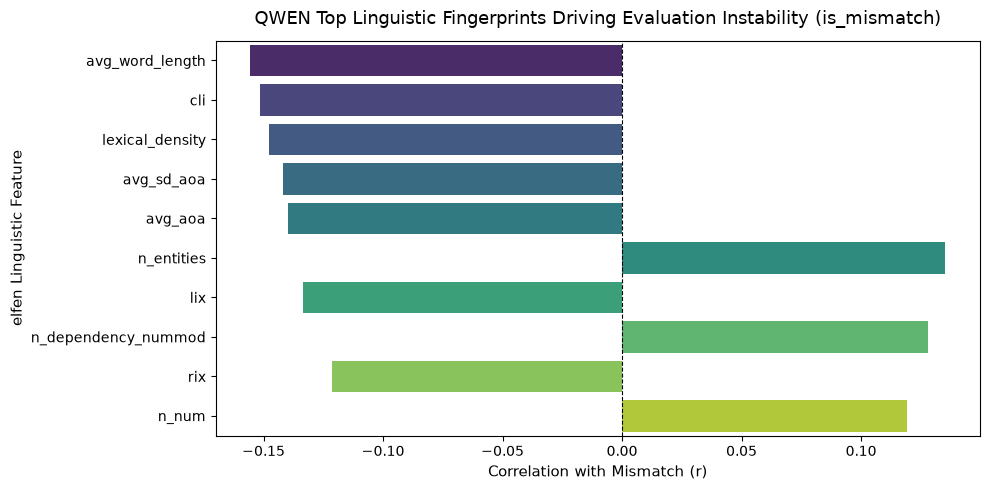

Real AUC: 0.572, Permutation p-value: 0.0100

--- QWEN: CLASSIFIER PERFORMANCE (5-fold CV) ---
Mean ROC-AUC: 0.572 (+/- 0.037)

Non-zero features after L1 selection: 68 / 294
n_low_iconicity                        0.174525
n_VERB_Aspect_Prog                    -0.159490
n_PRON_Gender_Fem                      0.157325
n_dependency_nummod                    0.155660
n_positive_sentiment                  -0.155542
n_work_of_art                         -0.141234
n_controversial_Haptic_sensorimotor   -0.133107
n_PRON_Gender_Masc                     0.132882
entropy                               -0.129130
n_dependency_dobj                      0.120943
tree_width                             0.108521
n_PRON_Number_Plur                    -0.106230
n_DET_Definite_Def                    -0.106043
n_high_Foot_leg_sensorimotor           0.095693
n_dependency_poss                     -0.094327
dtype: float64


/var/folders/qq/rf2gf30141s28phs4y6xh_lw0000gn/T/ipykernel_97226/1145025281.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=nonzero.values, y=nonzero.index, palette="viridis")


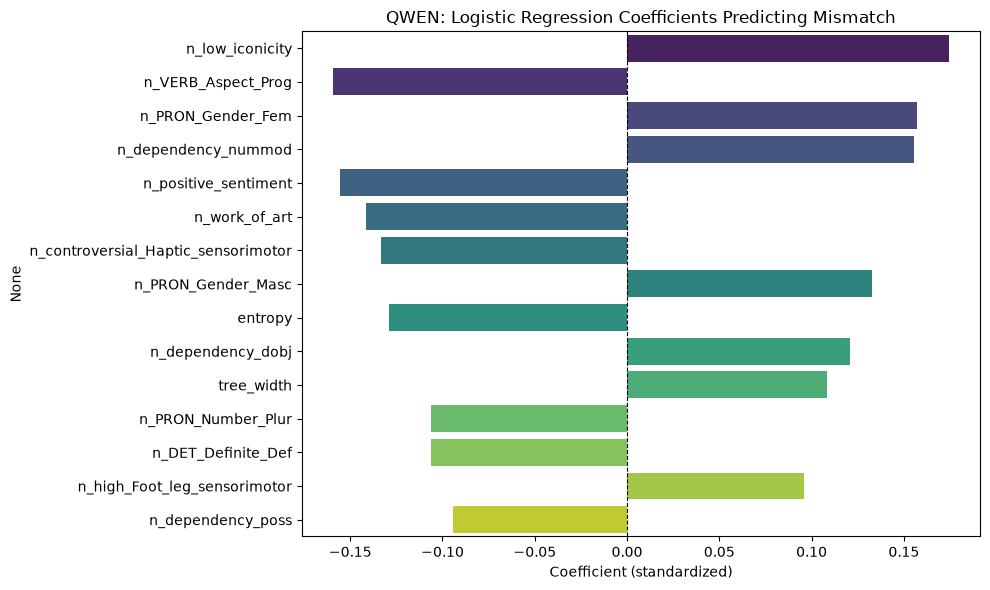


Running permutation test for QWEN (this takes a bit)...
Permutation test — AUC: 0.572, p-value: 0.0100


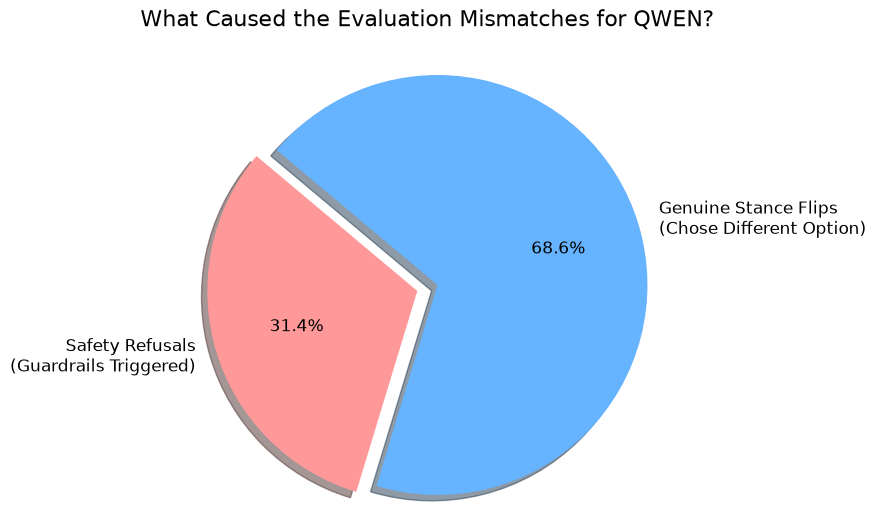

Total Mismatches Analyzed: 417
Mismatches due to Safety Refusals: 131
Mismatches due to Stance Flips: 286
Preparing data for t-SNE...
Scaling features...
Running t-SNE projection (this may take a moment)...
Plotting the clusters...


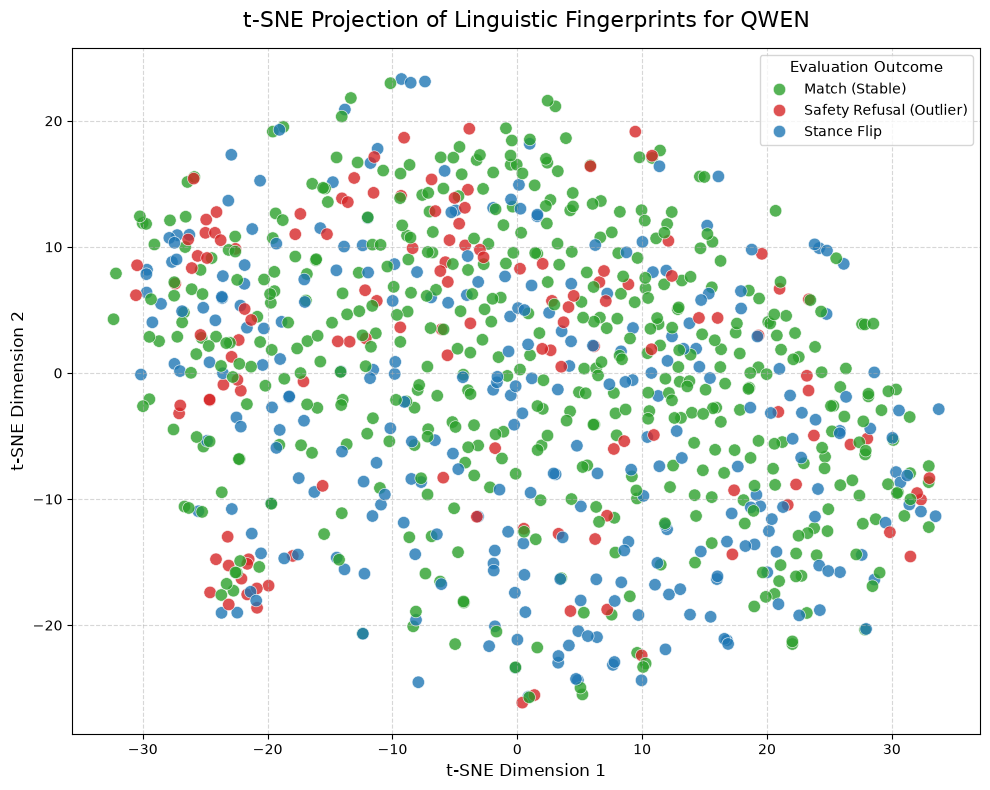

##########################################
Starting the visualization of HuggingFaceTB
--------------------------------------

Initializing elfen feature extractor...
Extracting 1,061 linguistic features...
Extracting raw_sequence_length...
Extracting n_tokens...
Extracting n_sentences...
Extracting n_tokens_per_sentence...
Extracting n_characters...
Extracting avg_word_length...
Extracting n_types...
Extracting n_long_words...
Extracting n_lemmas...
Extracting n_per_morph_feature...
Extracting tree_width...


/Users/ayanguin/.venv-vllm-metal/lib/python3.12/site-packages/elfen/dependency.py:57: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.
  data = data.with_columns(


Extracting tree_depth...


/Users/ayanguin/.venv-vllm-metal/lib/python3.12/site-packages/elfen/dependency.py:95: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.
  data = data.with_columns(


Extracting tree_branching...


/Users/ayanguin/.venv-vllm-metal/lib/python3.12/site-packages/elfen/dependency.py:128: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.
  data = data.with_columns(


Extracting n_noun_chunks...
Extracting n_per_dependency_type...


/Users/ayanguin/.venv-vllm-metal/lib/python3.12/site-packages/elfen/dependency.py:196: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.
  data = data.with_columns(


Extracting sentiment_score...
Extracting n_negative_sentiment...
Extracting n_positive_sentiment...
Extracting avg_valence...
Extracting n_low_valence...
Extracting n_high_valence...
Extracting avg_arousal...
Extracting n_low_arousal...
Extracting n_high_arousal...
Extracting avg_dominance...
Extracting n_low_dominance...
Extracting n_high_dominance...
Extracting avg_emotion_intensity...
Extracting n_low_intensity...
Extracting n_high_intensity...
Extracting compressibility...
Extracting entropy...
Extracting lemma_token_ratio...
Extracting ttr...
Extracting rttr...
Extracting cttr...
Extracting herdan_c...
Extracting summer_index...
Extracting dougast_u...
Extracting maas_index...
Extracting lexical_density...
Extracting n_hapax_legomena...
Extracting n_global_token_hapax_legomena...
Extracting n_global_lemma_hapax_legomena...
Extracting n_hapax_dislegomena...
Extracting n_global_token_hapax_dislegomena...
Extracting n_global_lemma_hapax_dislegomena...
Extracting sichel_s...
Extractin

/var/folders/qq/rf2gf30141s28phs4y6xh_lw0000gn/T/ipykernel_97226/3034964229.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlations[top_features.index].values, y=top_features.index, palette="viridis")


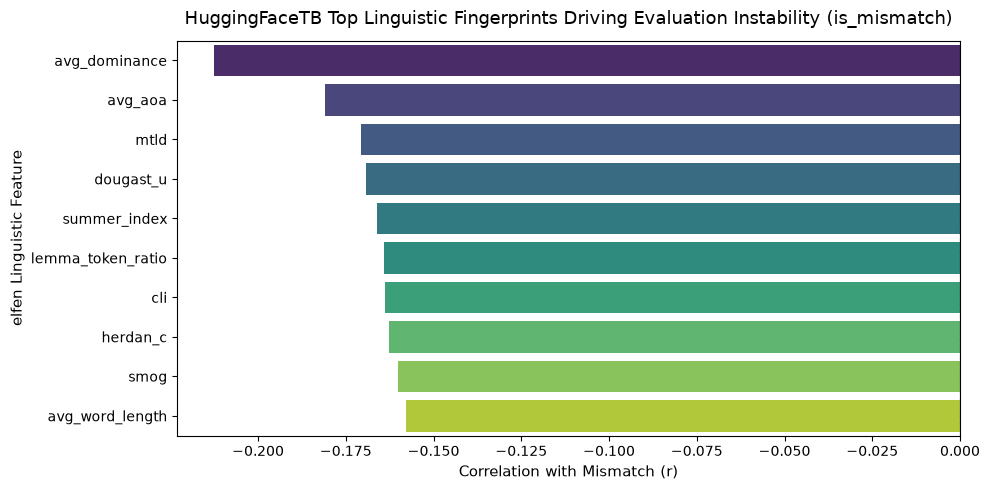

Real AUC: 0.630, Permutation p-value: 0.0050

--- HuggingFaceTB: CLASSIFIER PERFORMANCE (5-fold CV) ---
Mean ROC-AUC: 0.630 (+/- 0.031)

Non-zero features after L1 selection: 75 / 291
avg_prevalence                   0.201610
n_high_intensity_anticipation   -0.181633
n_low_dominance                  0.178766
avg_sd_Olfactory_sensorimotor    0.145940
n_hedges                         0.136823
n_low_Visual_sensorimotor        0.123898
avg_aoa                         -0.121780
avg_dominance                   -0.114568
n_dependency_preconj             0.109862
n_PUNCT_PunctType_Quot          -0.102130
n_high_concreteness             -0.099459
n_high_aoa                      -0.096062
avg_sd_Visual_sensorimotor      -0.095027
n_positive_sentiment            -0.092835
n_dependency_det                 0.091780
dtype: float64


/var/folders/qq/rf2gf30141s28phs4y6xh_lw0000gn/T/ipykernel_97226/1145025281.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=nonzero.values, y=nonzero.index, palette="viridis")


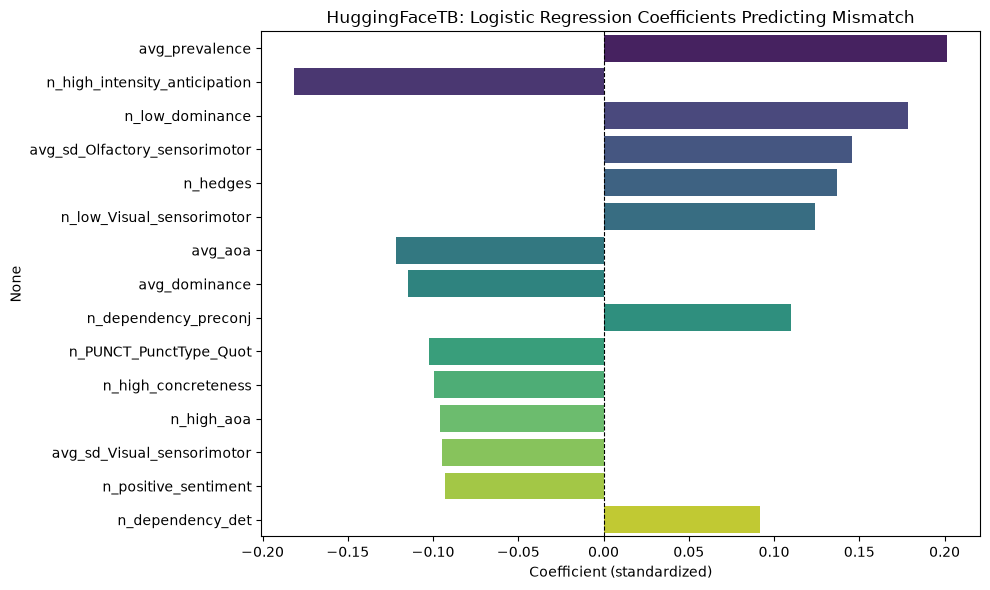


Running permutation test for HuggingFaceTB (this takes a bit)...
Permutation test — AUC: 0.630, p-value: 0.0050


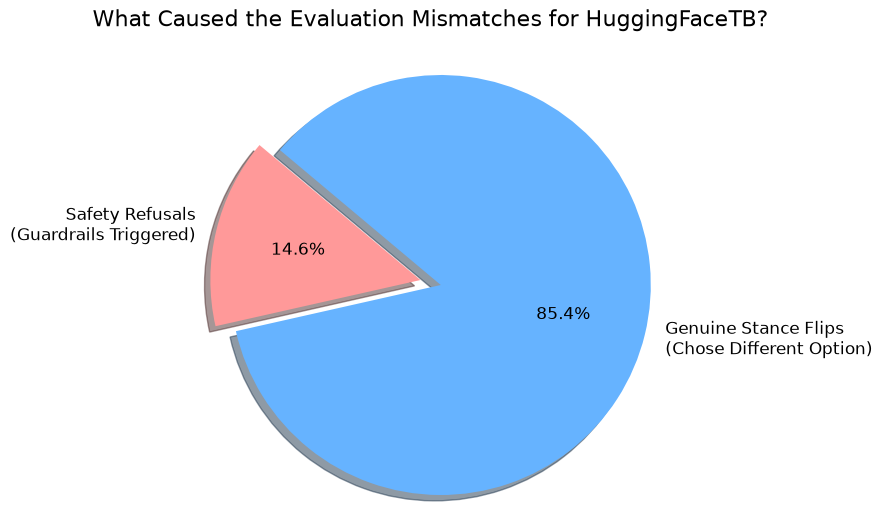

Total Mismatches Analyzed: 444
Mismatches due to Safety Refusals: 65
Mismatches due to Stance Flips: 379
Preparing data for t-SNE...
Scaling features...
Running t-SNE projection (this may take a moment)...
Plotting the clusters...


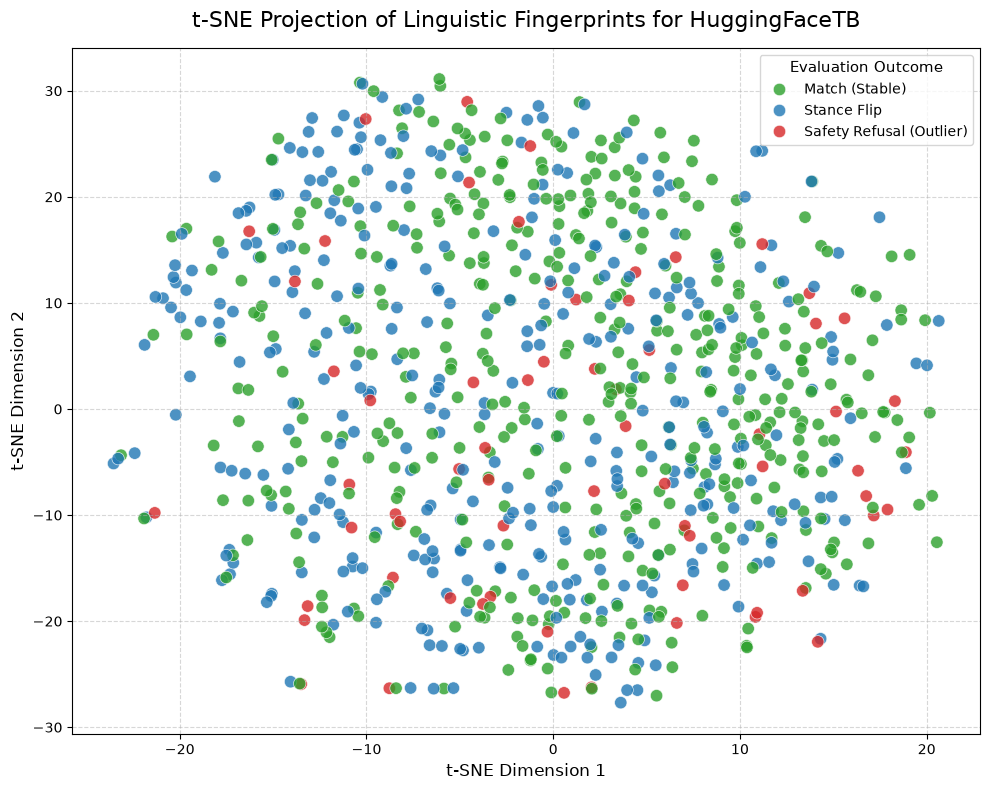

##########################################
Starting the visualization of mistralai
--------------------------------------

Initializing elfen feature extractor...
Extracting 1,061 linguistic features...
Extracting raw_sequence_length...
Extracting n_tokens...
Extracting n_sentences...
Extracting n_tokens_per_sentence...
Extracting n_characters...
Extracting avg_word_length...
Extracting n_types...
Extracting n_long_words...
Extracting n_lemmas...
Extracting n_per_morph_feature...
Extracting tree_width...


/Users/ayanguin/.venv-vllm-metal/lib/python3.12/site-packages/elfen/dependency.py:57: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.
  data = data.with_columns(
/Users/ayanguin/.venv-vllm-metal/lib/python3.12/site-packages/elfen/dependency.py:95: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.
  data = data.with_columns(


Extracting tree_depth...
Extracting tree_branching...


/Users/ayanguin/.venv-vllm-metal/lib/python3.12/site-packages/elfen/dependency.py:128: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.
  data = data.with_columns(


Extracting n_noun_chunks...
Extracting n_per_dependency_type...


/Users/ayanguin/.venv-vllm-metal/lib/python3.12/site-packages/elfen/dependency.py:196: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.
  data = data.with_columns(


Extracting sentiment_score...
Extracting n_negative_sentiment...
Extracting n_positive_sentiment...
Extracting avg_valence...
Extracting n_low_valence...
Extracting n_high_valence...
Extracting avg_arousal...
Extracting n_low_arousal...
Extracting n_high_arousal...
Extracting avg_dominance...
Extracting n_low_dominance...
Extracting n_high_dominance...
Extracting avg_emotion_intensity...
Extracting n_low_intensity...
Extracting n_high_intensity...
Extracting compressibility...
Extracting entropy...
Extracting lemma_token_ratio...
Extracting ttr...
Extracting rttr...
Extracting cttr...
Extracting herdan_c...
Extracting summer_index...
Extracting dougast_u...
Extracting maas_index...
Extracting lexical_density...
Extracting n_hapax_legomena...
Extracting n_global_token_hapax_legomena...
Extracting n_global_lemma_hapax_legomena...
Extracting n_hapax_dislegomena...
Extracting n_global_token_hapax_dislegomena...
Extracting n_global_lemma_hapax_dislegomena...
Extracting sichel_s...
Extractin

/Users/ayanguin/.venv-vllm-metal/lib/python3.12/site-packages/numpy/lib/function_base.py:2742: RuntimeWarning: invalid value encountered in subtract
  X -= avg[:, None]
/var/folders/qq/rf2gf30141s28phs4y6xh_lw0000gn/T/ipykernel_97226/3034964229.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlations[top_features.index].values, y=top_features.index, palette="viridis")


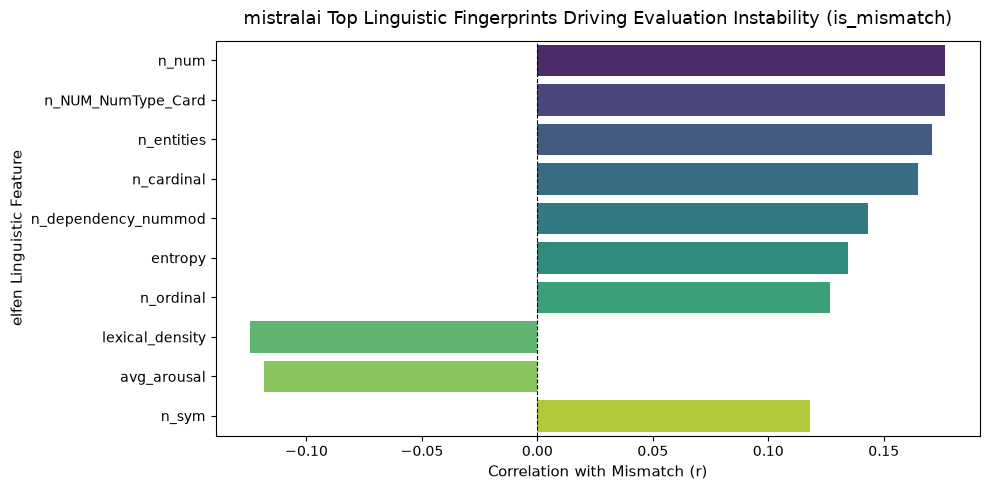

Real AUC: 0.660, Permutation p-value: 0.0050

--- mistralai: CLASSIFIER PERFORMANCE (5-fold CV) ---
Mean ROC-AUC: 0.660 (+/- 0.039)

Non-zero features after L1 selection: 83 / 291
avg_Olfactory_sensorimotor          -0.289019
n_PUNCT_PunctSide_Fin               -0.262764
n_DET_Number_Plur                   -0.250762
n_PRON_Gender_Fem                    0.216069
n_dependency_compound               -0.205395
n_dependency_advmod                  0.190212
n_low_intensity_disgust             -0.183170
n_dependency_poss                   -0.170073
n_ordinal                            0.152468
n_VERB_Aspect_Prog                  -0.144676
n_PRON_PronType_Dem                 -0.135719
avg_sd_Interoceptive_sensorimotor    0.133796
n_hapax_legomena                    -0.126053
n_product                            0.124586
n_dependency_prt                    -0.121565
dtype: float64


/var/folders/qq/rf2gf30141s28phs4y6xh_lw0000gn/T/ipykernel_97226/1145025281.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=nonzero.values, y=nonzero.index, palette="viridis")


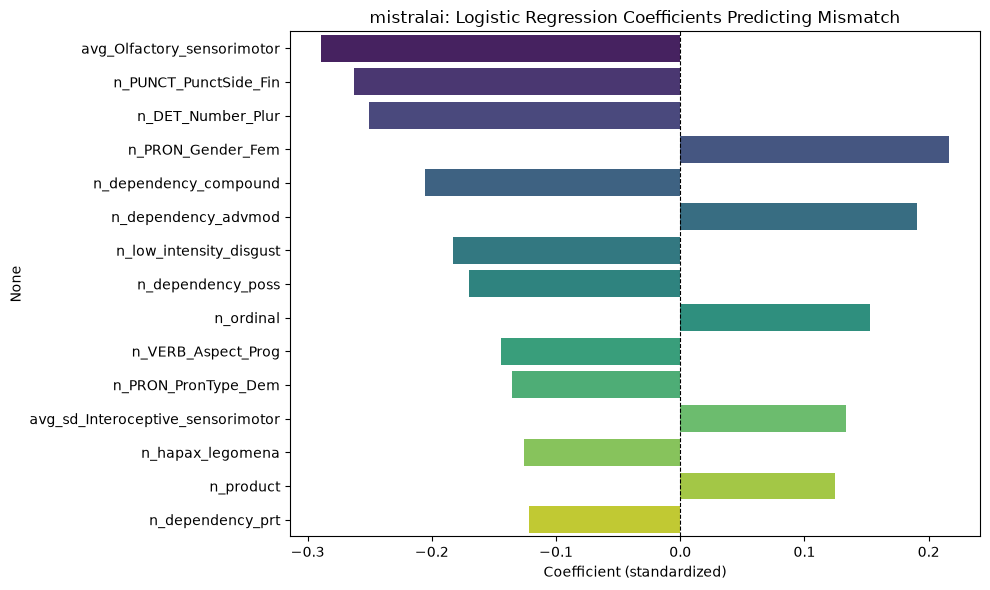


Running permutation test for mistralai (this takes a bit)...
Permutation test — AUC: 0.660, p-value: 0.0050


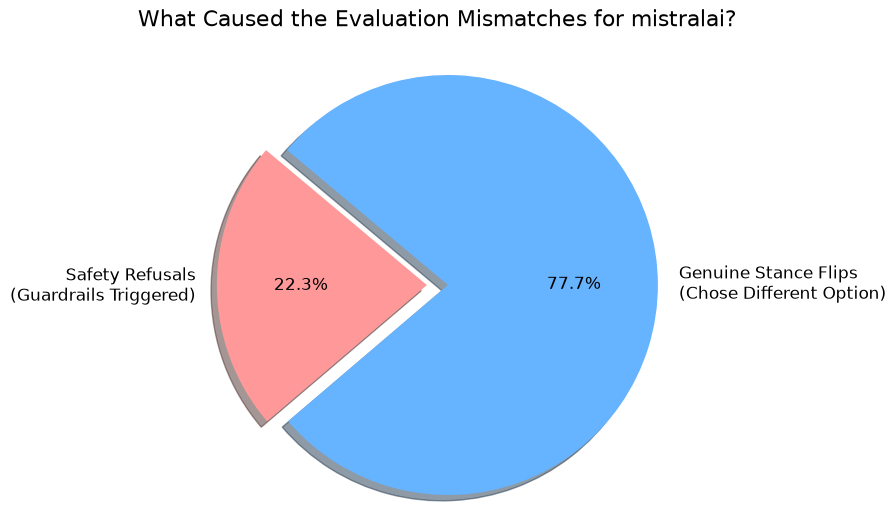

Total Mismatches Analyzed: 264
Mismatches due to Safety Refusals: 59
Mismatches due to Stance Flips: 205
Preparing data for t-SNE...
Scaling features...
Running t-SNE projection (this may take a moment)...
Plotting the clusters...


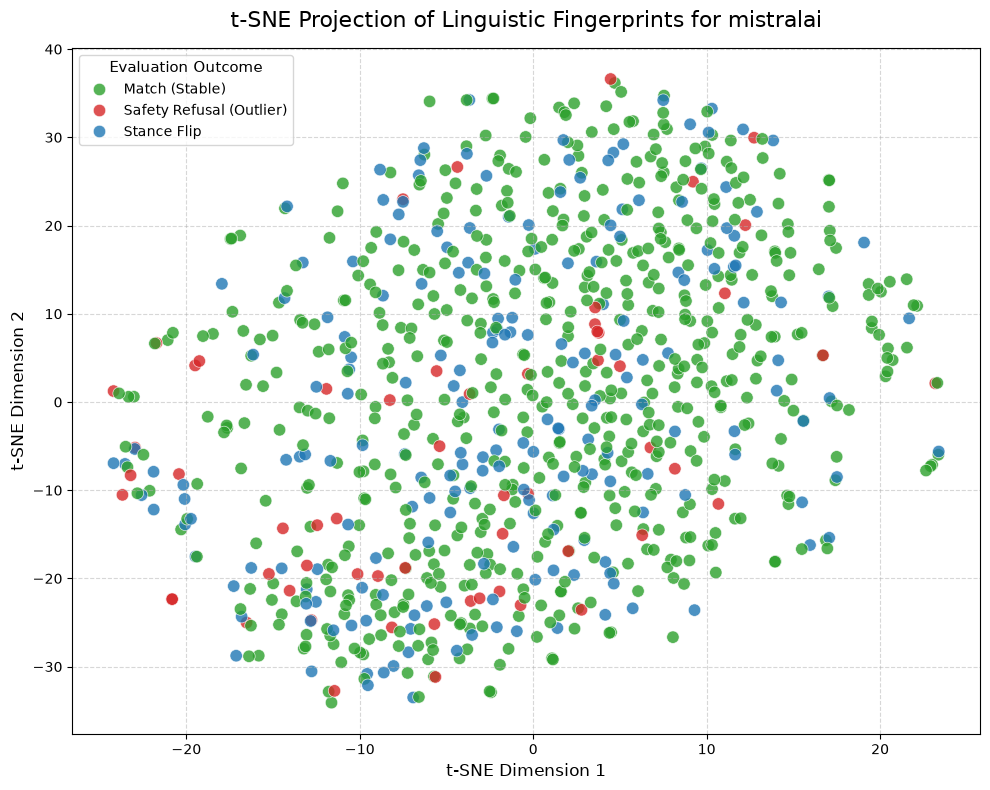

##########################################
Starting the visualization of google
--------------------------------------

Initializing elfen feature extractor...
Extracting 1,061 linguistic features...
Extracting raw_sequence_length...
Extracting n_tokens...
Extracting n_sentences...
Extracting n_tokens_per_sentence...
Extracting n_characters...
Extracting avg_word_length...
Extracting n_types...
Extracting n_long_words...
Extracting n_lemmas...
Extracting n_per_morph_feature...
Extracting tree_width...


/Users/ayanguin/.venv-vllm-metal/lib/python3.12/site-packages/elfen/dependency.py:57: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.
  data = data.with_columns(
/Users/ayanguin/.venv-vllm-metal/lib/python3.12/site-packages/elfen/dependency.py:95: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.
  data = data.with_columns(


Extracting tree_depth...
Extracting tree_branching...
Extracting n_noun_chunks...


/Users/ayanguin/.venv-vllm-metal/lib/python3.12/site-packages/elfen/dependency.py:128: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.
  data = data.with_columns(
/Users/ayanguin/.venv-vllm-metal/lib/python3.12/site-packages/elfen/dependency.py:196: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.
  data = data.with_columns(


Extracting n_per_dependency_type...
Extracting sentiment_score...
Extracting n_negative_sentiment...
Extracting n_positive_sentiment...
Extracting avg_valence...
Extracting n_low_valence...
Extracting n_high_valence...
Extracting avg_arousal...
Extracting n_low_arousal...
Extracting n_high_arousal...
Extracting avg_dominance...
Extracting n_low_dominance...
Extracting n_high_dominance...
Extracting avg_emotion_intensity...
Extracting n_low_intensity...
Extracting n_high_intensity...
Extracting compressibility...
Extracting entropy...
Extracting lemma_token_ratio...
Extracting ttr...
Extracting rttr...
Extracting cttr...
Extracting herdan_c...
Extracting summer_index...
Extracting dougast_u...
Extracting maas_index...
Extracting lexical_density...
Extracting n_hapax_legomena...
Extracting n_global_token_hapax_legomena...
Extracting n_global_lemma_hapax_legomena...
Extracting n_hapax_dislegomena...
Extracting n_global_token_hapax_dislegomena...
Extracting n_global_lemma_hapax_dislegomena

/var/folders/qq/rf2gf30141s28phs4y6xh_lw0000gn/T/ipykernel_97226/3034964229.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlations[top_features.index].values, y=top_features.index, palette="viridis")


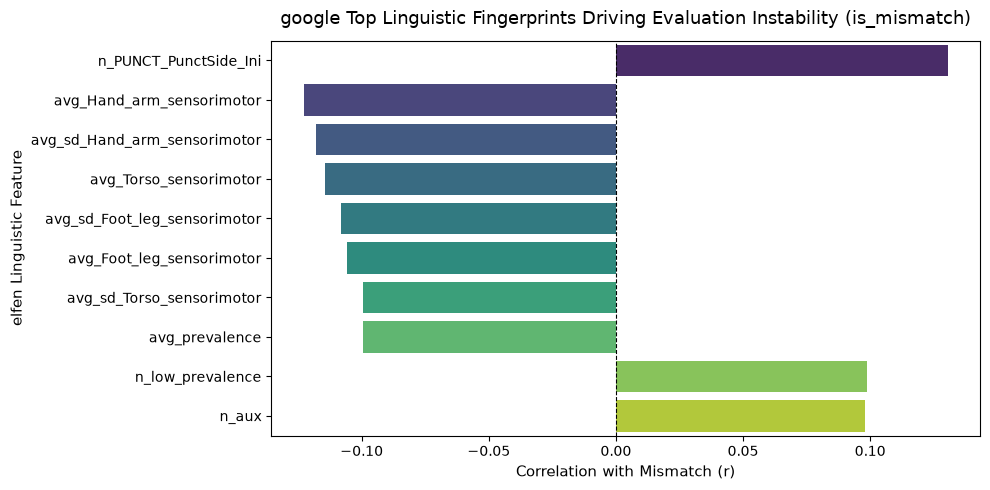

Real AUC: 0.608, Permutation p-value: 0.0050

--- google: CLASSIFIER PERFORMANCE (5-fold CV) ---
Mean ROC-AUC: 0.608 (+/- 0.023)

Non-zero features after L1 selection: 96 / 291
n_PUNCT_PunctSide_Ini                0.308117
n_global_token_hapax_legomena       -0.221190
avg_dominance                       -0.207963
avg_sd_Interoceptive_sensorimotor    0.189786
n_PUNCT_PunctType_Comm               0.182074
n_high_Hand_arm_sensorimotor        -0.173715
n_low_intensity_anger               -0.161594
n_high_arousal                       0.161293
n_PRON_PronType_Ind                 -0.154085
avg_sd_Hand_arm_sensorimotor        -0.143701
n_dependency_pcomp                  -0.138636
n_PROPN_Number_Plur                 -0.134503
n_high_Gustatory_sensorimotor       -0.128510
n_dependency_neg                     0.127352
n_dependency_advcl                  -0.126602
dtype: float64


/var/folders/qq/rf2gf30141s28phs4y6xh_lw0000gn/T/ipykernel_97226/1145025281.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=nonzero.values, y=nonzero.index, palette="viridis")


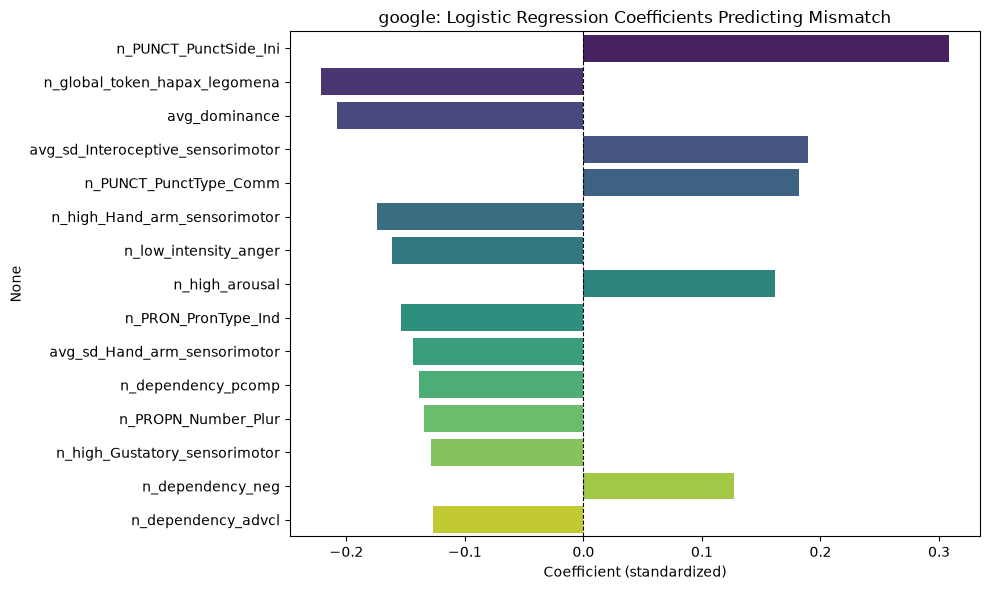


Running permutation test for google (this takes a bit)...
Permutation test — AUC: 0.608, p-value: 0.0050


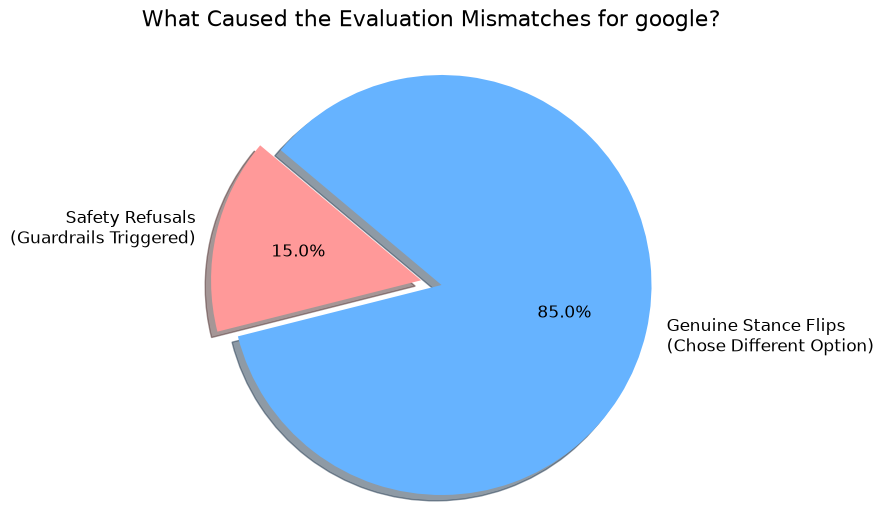

Total Mismatches Analyzed: 226
Mismatches due to Safety Refusals: 34
Mismatches due to Stance Flips: 192
Preparing data for t-SNE...
Scaling features...
Running t-SNE projection (this may take a moment)...
Plotting the clusters...


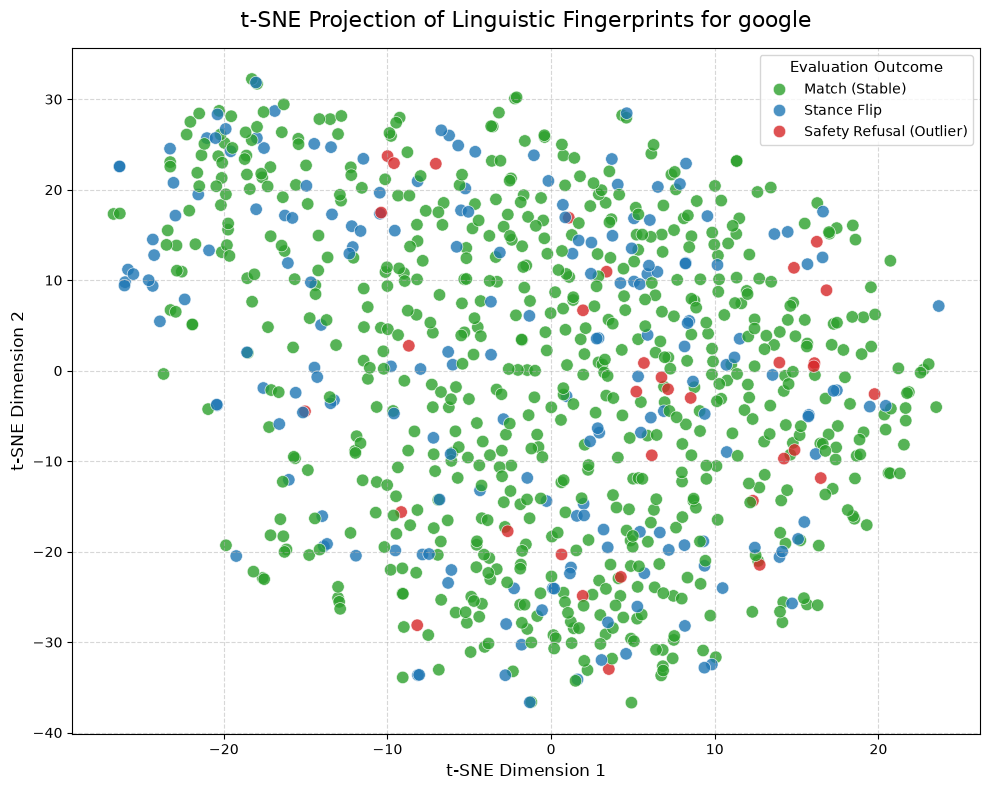

##########################################
Starting the visualization of meta-llama
--------------------------------------

Initializing elfen feature extractor...
Extracting 1,061 linguistic features...
Extracting raw_sequence_length...
Extracting n_tokens...
Extracting n_sentences...
Extracting n_tokens_per_sentence...
Extracting n_characters...
Extracting avg_word_length...
Extracting n_types...
Extracting n_long_words...
Extracting n_lemmas...
Extracting n_per_morph_feature...
Extracting tree_width...


/Users/ayanguin/.venv-vllm-metal/lib/python3.12/site-packages/elfen/dependency.py:57: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.
  data = data.with_columns(


Extracting tree_depth...


/Users/ayanguin/.venv-vllm-metal/lib/python3.12/site-packages/elfen/dependency.py:95: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.
  data = data.with_columns(


Extracting tree_branching...


/Users/ayanguin/.venv-vllm-metal/lib/python3.12/site-packages/elfen/dependency.py:128: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.
  data = data.with_columns(


Extracting n_noun_chunks...
Extracting n_per_dependency_type...


/Users/ayanguin/.venv-vllm-metal/lib/python3.12/site-packages/elfen/dependency.py:196: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.
  data = data.with_columns(


Extracting sentiment_score...
Extracting n_negative_sentiment...
Extracting n_positive_sentiment...
Extracting avg_valence...
Extracting n_low_valence...
Extracting n_high_valence...
Extracting avg_arousal...
Extracting n_low_arousal...
Extracting n_high_arousal...
Extracting avg_dominance...
Extracting n_low_dominance...
Extracting n_high_dominance...
Extracting avg_emotion_intensity...
Extracting n_low_intensity...
Extracting n_high_intensity...
Extracting compressibility...
Extracting entropy...
Extracting lemma_token_ratio...
Extracting ttr...
Extracting rttr...
Extracting cttr...
Extracting herdan_c...
Extracting summer_index...
Extracting dougast_u...
Extracting maas_index...
Extracting lexical_density...
Extracting n_hapax_legomena...
Extracting n_global_token_hapax_legomena...
Extracting n_global_lemma_hapax_legomena...
Extracting n_hapax_dislegomena...
Extracting n_global_token_hapax_dislegomena...
Extracting n_global_lemma_hapax_dislegomena...
Extracting sichel_s...
Extractin

/var/folders/qq/rf2gf30141s28phs4y6xh_lw0000gn/T/ipykernel_97226/3034964229.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlations[top_features.index].values, y=top_features.index, palette="viridis")


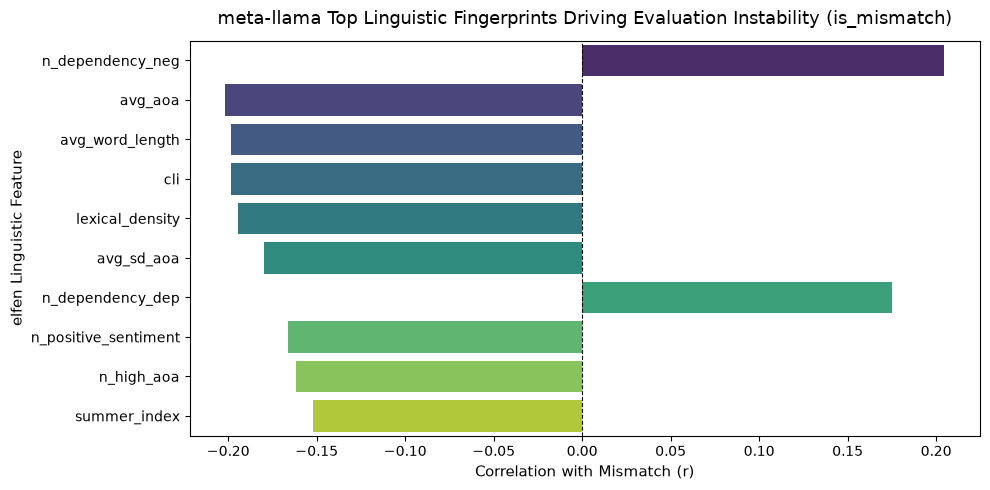

Real AUC: 0.661, Permutation p-value: 0.0050

--- meta-llama: CLASSIFIER PERFORMANCE (5-fold CV) ---
Mean ROC-AUC: 0.661 (+/- 0.045)

Non-zero features after L1 selection: 75 / 291
n_dependency_neg                              0.372352
n_positive_sentiment                         -0.168255
n_dependency_mark                             0.168248
n_PRON_Case_Acc                              -0.162545
n_dependency_dep                              0.134804
n_high_aoa                                   -0.131794
n_PUNCT_PunctType_Brck                        0.123352
n_high_intensity_joy                         -0.116590
n_controversial_Interoceptive_sensorimotor    0.115136
n_low_intensity_surprise                      0.113923
avg_sd_Auditory_sensorimotor                 -0.111323
n_product                                     0.111076
herdan_v                                      0.109082
n_high_concreteness                          -0.107810
n_low_dominance                              -0.1

/var/folders/qq/rf2gf30141s28phs4y6xh_lw0000gn/T/ipykernel_97226/1145025281.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=nonzero.values, y=nonzero.index, palette="viridis")


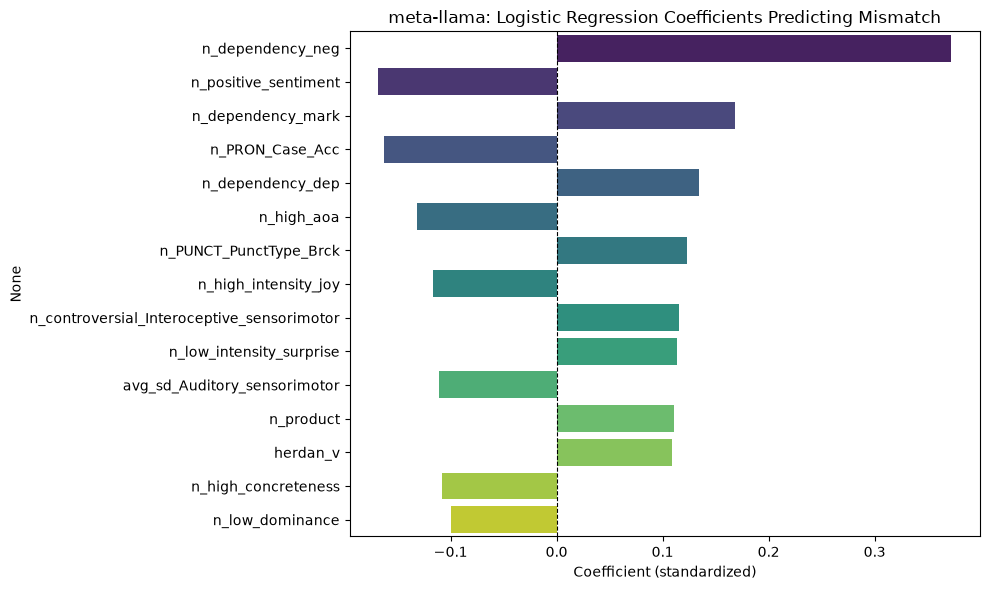


Running permutation test for meta-llama (this takes a bit)...
Permutation test — AUC: 0.661, p-value: 0.0050


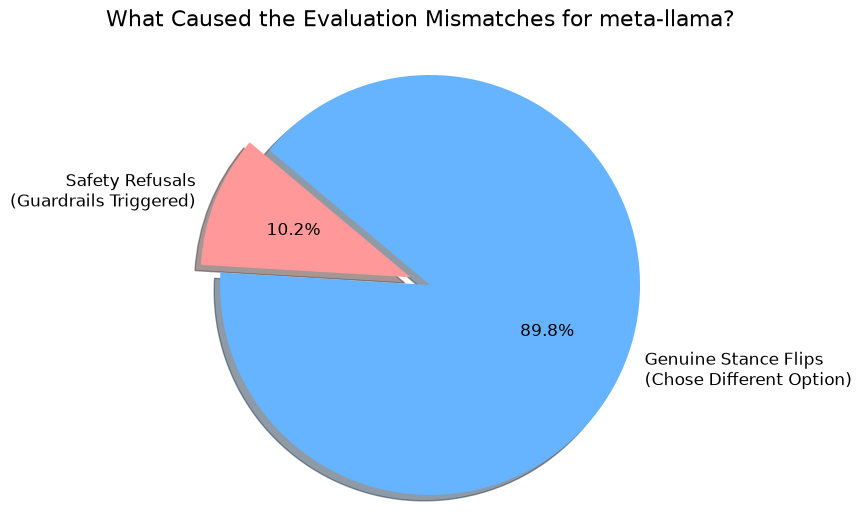

Total Mismatches Analyzed: 305
Mismatches due to Safety Refusals: 31
Mismatches due to Stance Flips: 274
Preparing data for t-SNE...
Scaling features...
Running t-SNE projection (this may take a moment)...
Plotting the clusters...


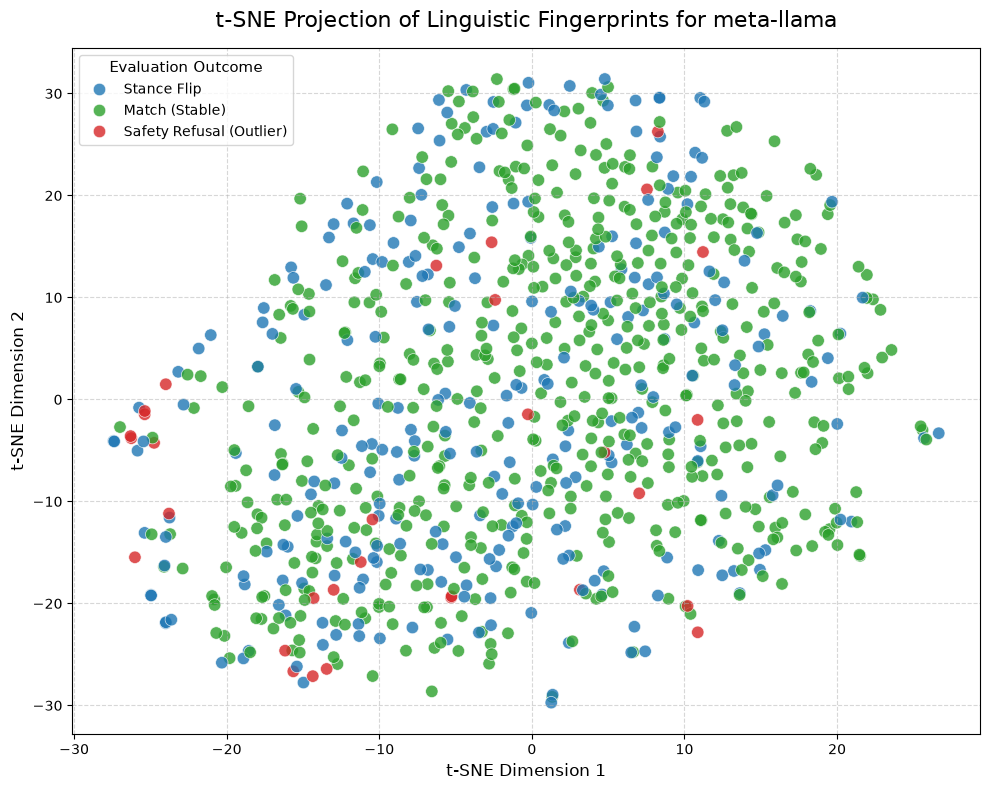

##########################################
*************************************************
QWEN: AUC=0.572 (+/-0.037), p=0.009950248756218905
HuggingFaceTB: AUC=0.630 (+/-0.031), p=0.004975124378109453
mistralai: AUC=0.660 (+/-0.039), p=0.004975124378109453
google: AUC=0.608 (+/-0.023), p=0.004975124378109453
meta-llama: AUC=0.661 (+/-0.045), p=0.004975124378109453
*************************************************


In [12]:
results = {}
for key in dataframes:
    print(f"Starting the visualization of {key}")
    print("--------------------------------------")
    elfen_feature(dataframes[key], key)
    
    csv = f"/Users/ayanguin/Documents/UniTrier/NLP/NLP/Poster/result/{key}_sample_features.csv"
    
    
    ling_finger(csv, key)
    results[key] = mismatch_classifier(csv, key)
    mismatch_plot(csv, key)
    tSNE(csv, key)
    print("##########################################")

print("*************************************************")
for key, r in results.items():
    print(f"{key}: AUC={r['auc_mean']:.3f} (+/-{r['auc_std']:.3f}), p={r['p_value']}")
print("*************************************************")


